# Internship Scam Detection using Machine Learning
#### Module: Binary Classification

---

### Project Aim & Objective
The primary goal of this project is to build an end-to-end machine learning pipeline that automatically identifies and classifies fraudulent internship postings. This notebook serves as a practical, beginner-friendly guide to detecting these malicious postings using metadata analytics.

---

### Pipeline Architecture
1. **Exploratory Data Analysis (EDA)**
2. **Train-Test Separation**
3. **Data Imputation & Preprocessing**
4. **Model Training**
5. **Evaluation**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Basic data exploration

In [24]:
import gdown
import os

file_id = '1JzvRWYKAjDbjhuVZSMJvIbGJryxyVKQo'
url = f'https://drive.google.com/uc?id={file_id}'
output_path = '../data/internship_scam_data.csv'

os.makedirs('../data', exist_ok=True)

gdown.download(url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1JzvRWYKAjDbjhuVZSMJvIbGJryxyVKQo
To: c:\Users\Naina Bhatnagar\ML-CaPsule\data\internship_scam_data.csv
100%|██████████| 350k/350k [00:00<00:00, 1.96MB/s]


'../data/internship_scam_data.csv'

In [25]:
df = pd.read_csv("../data/internship_scam_data.csv")
cols = ['internship_title', 'employment_type', 'work_mode', 'industry', 
        'location', 'company_name', 'company_size', 'stipend', 
        'payment_required', 'registration_fee', 'recruiter_email_type', 
        'website_available', 'is_fake_posting']

df = df[cols]
df.head()

,internship_title,employment_type,work_mode,industry,location,company_name,company_size,stipend,payment_required,registration_fee,recruiter_email_type,website_available,is_fake_posting
0,Cloud Engineer,Full-Time,Remote,Marketing,Sydney,Bradford Ltd,Small,37251.0,1,2953,Corporate,1,1
1,Backend Developer,Part-Time,Onsite,EdTech,Toronto,"Willis, Adams and Edwards",Medium,46242.0,0,0,Corporate,0,0
2,Frontend Developer,Part-Time,Hybrid,Software,Bangalore,"Green, Allen and Harvey",Startup,42231.0,0,0,Free,1,1
3,Cloud Engineer,Full-Time,Remote,Software,Singapore,Brown Ltd,Medium,38152.0,0,0,Corporate,1,0
4,Backend Developer,Part-Time,Onsite,Healthcare,Sydney,Bryan LLC,Startup,38447.0,1,1111,Corporate,1,1


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   internship_title      2000 non-null   str    
 1   employment_type       2000 non-null   str    
 2   work_mode             2000 non-null   str    
 3   industry              2000 non-null   str    
 4   location              2000 non-null   str    
 5   company_name          2000 non-null   str    
 6   company_size          2000 non-null   str    
 7   stipend               1970 non-null   float64
 8   payment_required      2000 non-null   int64  
 9   registration_fee      2000 non-null   int64  
 10  recruiter_email_type  2000 non-null   str    
 11  website_available     2000 non-null   int64  
 12  is_fake_posting       2000 non-null   int64  
dtypes: float64(1), int64(4), str(8)
memory usage: 203.3 KB


Null columns: `stipend`: a numerical column
#### Strategy for replacing NULLS:
1. `stipend` : value 0

## EDA

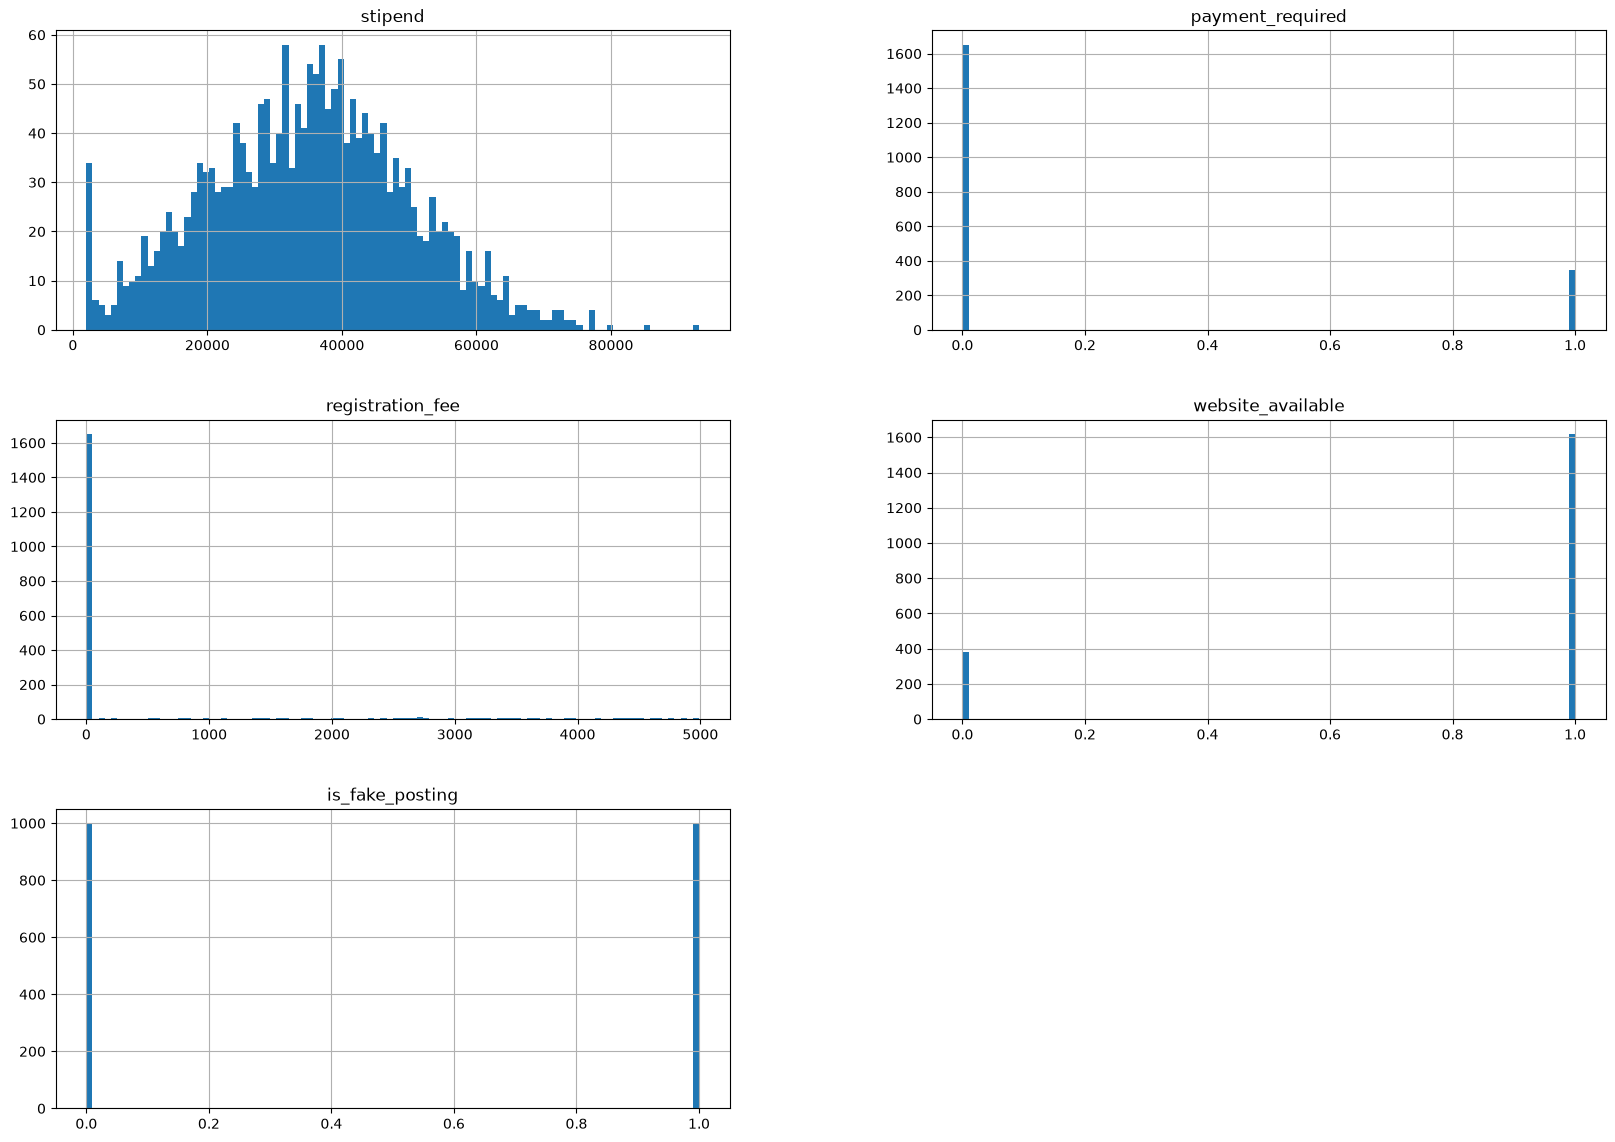

In [27]:
df.hist(bins=100, figsize=(20,14))
plt.show()

In [28]:
df["stipend"].min()

np.float64(2000.0)

> stipend is capped at 2000, uncapped on the upper bound. Our strategy of replacing Nan stipend with 0s persists.

---
### correlation between all numeric columns and `is_fake_posting`

In [29]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix["is_fake_posting"].sort_values(ascending=False)

is_fake_posting      1.000000
payment_required     0.358735
registration_fee     0.306164
stipend             -0.040142
website_available   -0.184621
Name: is_fake_posting, dtype: float64

In [30]:
for col in df.select_dtypes(include='str').columns:
    print(df[col].value_counts())

internship_title
Marketing Intern         246
ML Engineer              243
Frontend Developer       232
AI Research Intern       221
Backend Developer        219
Cloud Engineer           216
UI/UX Designer           212
Cybersecurity Analyst    211
Data Science Intern      200
Name: count, dtype: int64
employment_type
Internship    521
Contract      508
Full-Time     490
Part-Time     481
Name: count, dtype: int64
work_mode
Remote    1138
Hybrid     452
Onsite     410
Name: count, dtype: int64
industry
Marketing        254
Gaming           230
EdTech           228
Healthcare       228
Cybersecurity    222
Software         214
FinTech          214
E-Commerce       213
AI               197
Name: count, dtype: int64
location
Toronto          253
Bangalore        227
Dubai            226
Berlin           224
Sydney           223
London           217
Singapore        214
San Francisco    213
New York         203
Name: count, dtype: int64
company_name
Johnson Inc                 6
Smith LLC 

In [31]:
df.columns

Index(['internship_title', 'employment_type', 'work_mode', 'industry',
       'location', 'company_name', 'company_size', 'stipend',
       'payment_required', 'registration_fee', 'recruiter_email_type',
       'website_available', 'is_fake_posting'],
      dtype='str')

### Drop not-so-useful columns
1. High Cardinality Fields: `company_name`, `internship_title`, `location`, `employment_type`, `industry`


In [32]:
df.drop(['company_name', 'internship_title', 'location', 'employment_type', 'industry'], axis=1, inplace=True)

### Train Test Split

In [33]:
# split into X and y
X = df.drop(columns=['is_fake_posting'])
y = df['is_fake_posting']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
X_train.columns

Index(['work_mode', 'company_size', 'stipend', 'payment_required',
       'registration_fee', 'recruiter_email_type', 'website_available'],
      dtype='str')

segregating numerical and categorical columns

In [36]:
# Automatically collect all other clean numeric features
all_numeric = X.select_dtypes(include=[np.number]).columns.tolist()
clean_numeric_cols = [c for c in all_numeric if c not in (['stipend'])]

# Automatically collect categorical columns for encoding
categorical_cols = X.select_dtypes(include=['str']).columns.tolist()

### Automated ColumnTransformer Pipelines

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Build individual step pipelines
stipend_pipeline = Pipeline([
    ('imputer_zero', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

numeric_clean_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [38]:
# Assemble everything into a single ColumnTransformer layout
preprocessing_pipeline = ColumnTransformer(transformers=[
    ('stipend_path', stipend_pipeline, ['stipend']),
    ('num_clean_path', numeric_clean_pipeline, clean_numeric_cols),
    ('cat_path', categorical_pipeline, categorical_cols)
])

### Baseline model: DecisionTreeClassifier

In [39]:
# Fit and transform the training split; transform the testing split cleanly
X_train_prepared = preprocessing_pipeline.fit_transform(X_train)
X_test_prepared = preprocessing_pipeline.transform(X_test)

### GridSearchCV Hyperparameter Tuning

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Initialize a base Decision Tree
base_tree = DecisionTreeClassifier(random_state=42)

# 2. Define the exact parameter grid you want to test
params = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

# 3. Set up the Grid Search engine
grid_search = GridSearchCV(
    estimator=base_tree, 
    param_grid=params, 
    cv=3, 
    scoring='f1_macro',
    verbose=1
)

print("Starting Grid Search across combinations...")
# 4. Run the search on your clean, prepared training data
grid_search.fit(X_train_prepared, y_train)

# 5. Print the mathematically optimal parameters discovered
print("\n--- Optimal Hyperparameters Found ---")
print(grid_search.best_params_)

# 6. Extract the best optimized model directly
best_tree_model = grid_search.best_estimator_

# 7. Predict and evaluate using the optimized model on your isolated test set
y_pred_opt = best_tree_model.predict(X_test_prepared)

print("\n--- Optimized Decision Tree Evaluation Report ---")
print(classification_report(y_test, y_pred_opt))

Starting Grid Search across combinations...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

--- Optimal Hyperparameters Found ---
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 20}

--- Optimized Decision Tree Evaluation Report ---
              precision    recall  f1-score   support

           0       0.65      0.78      0.71       197
           1       0.73      0.59      0.65       203

    accuracy                           0.68       400
   macro avg       0.69      0.68      0.68       400
weighted avg       0.69      0.68      0.68       400



In [41]:
feature_names = preprocessing_pipeline.get_feature_names_out()
importances = pd.Series(best_tree_model.feature_importances_, index=feature_names)
print(importances.sort_values(ascending=False))

num_clean_path__registration_fee            0.458352
cat_path__recruiter_email_type_Free         0.211730
num_clean_path__website_available           0.153797
stipend_path__stipend                       0.106322
cat_path__recruiter_email_type_Corporate    0.033454
cat_path__company_size_Small                0.025189
cat_path__work_mode_Onsite                  0.011155
cat_path__work_mode_Hybrid                  0.000000
num_clean_path__payment_required            0.000000
cat_path__company_size_Medium               0.000000
cat_path__company_size_Enterprise           0.000000
cat_path__work_mode_Remote                  0.000000
cat_path__company_size_Startup              0.000000
dtype: float64


### saving the model and the pipeline

In [42]:
import joblib

os.makedirs('../models', exist_ok=True)

joblib.dump(best_tree_model, '../models/model.pkl')
joblib.dump(preprocessing_pipeline, '../models/pipeline.pkl')

['../models/pipeline.pkl']

### Key Metrics:
* **Overall Accuracy: 70%**
* **Scam Precision: 74%**
* **Scam Recall: 63%**